In [2]:
%reload_ext autoreload
%autoreload 2

In [3]:
from kret_studies import *
from kret_studies.notebook import *
from kret_studies.complex import *

logger = get_notebook_logger()

Loaded environment variables from /Users/Akseldkw/coding/Columbia/RL-Project/.env.


INFO:datasets:JAX version 0.7.2 available.


In [4]:
from waymo_agent import *

In [5]:
G = ox.load_graphml(filepath=MAP_DIR / "manhattan.graphml")

In [6]:
# fig, ax = ox.plot_graph(G, node_size=0, edge_linewidth=0.5)

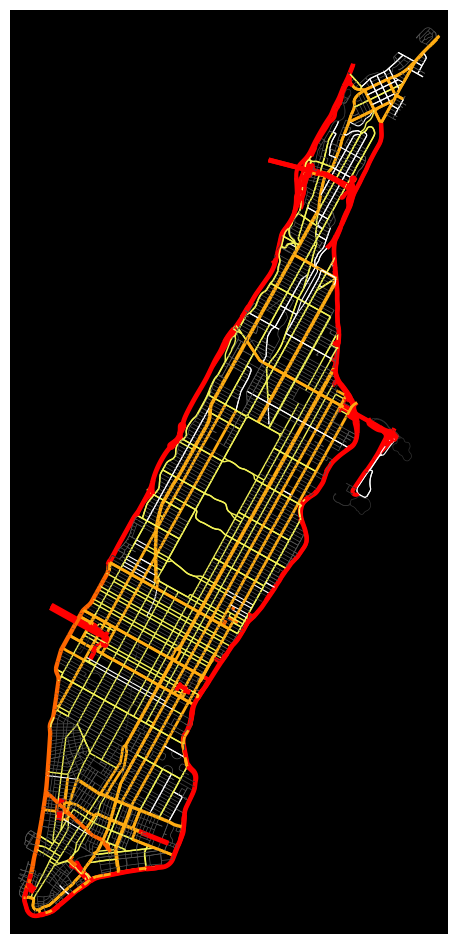

In [7]:
# 1. Load graph (if not already loaded)
# G = ox.load_graphml("manhattan.graphml")

# 2. Define mappings for Colors AND Widths
config = {
    "motorway": {"color": "#ff0000", "width": 3.0},  # Red, Thickest
    "motorway_link": {"color": "#ff0000", "width": 3.0},
    "trunk": {"color": "#ff6600", "width": 2.5},  # Orange, Thick
    "primary": {"color": "#ffac12", "width": 2.0},  # Gold, Medium-Thick
    "secondary": {"color": "#f4f458", "width": 1.0},  # Yellow, Medium
    "tertiary": {"color": "#ffffff", "width": 0.8},  # White, Thin
    "residential": {"color": "#555555", "width": 0.5},  # Grey, Thinnest
    "default": {"color": "#333333", "width": 0.5},  # Fallback
}

# 3. Generate the lists
edge_colors = []
edge_widths = []

for u, v, data in G.edges(data=True):
    # Get highway type (handle lists if necessary)
    highway_type = data.get("highway", "default")
    if isinstance(highway_type, list):
        highway_type = highway_type[0]

    # Fetch style from config, or use default if type not found
    style = config.get(highway_type, config["default"])

    edge_colors.append(style["color"])
    edge_widths.append(style["width"])

# 4. Plot with both attributes
fig, ax = ox.plot_graph(
    G,
    node_size=0,
    edge_color=edge_colors,
    edge_linewidth=edge_widths,  # <--- Pass the new list here
    bgcolor="black",
    figsize=(12, 12),  # Bigger size helps see the width differences
    show=True,
)

In [8]:
# fig.savefig(IMG_DIR / "manhattan_map.png", dpi=600, bbox_inches="tight", facecolor=fig.get_facecolor())

In [9]:
len(G.nodes), len(G.edges)

(4619, 9901)

## Sparsify the graph

In [10]:
G = ox.load_graphml(filepath=MAP_DIR / "manhattan.graphml")

In [11]:
G_sparse = sparsify_graph(G)

Removing 4782 non-major edges...
Graph after edge removal: 3505 nodes
Cleaning edge attributes before simplification...
Simplifying topology...


TypeError: unhashable type: 'list'